In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from linearmodels.datasets import mroz
from linearmodels.iv import IV2SLS
from scipy.stats import gaussian_kde
from statsmodels.api import add_constant

In [189]:
print(mroz.DESCR)
data = mroz.load()
data = data.dropna()
data = add_constant(data, has_constant="add")

columns_of_interest = ["wage", "educ", "fatheduc"]


T.A. Mroz (1987), "The Sensitivity of an Empirical Model of Married Women's
Hours of Work to Economic and Statistical Assumptions," Econometrica 55,
765-799.

nlf        1 if in labor force, 1975
hours      hours worked, 1975
kidslt6    # kids < 6 years
kidsge6    # kids 6-18
age        woman's age in yrs
educ       years of schooling
wage       estimated wage from earns., hours
repwage    reported wage at interview in 1976
hushrs     hours worked by husband, 1975
husage     husband's age
huseduc    husband's years of schooling
huswage    husband's hourly wage, 1975
faminc     family income, 1975
mtr        fed. marginal tax rate facing woman
motheduc   mother's years of schooling
fatheduc   father's years of schooling
unem       unem. rate in county of resid.
city       =1 if live in SMSA
exper      actual labor mkt exper
nwifeinc   (faminc - wage*hours)/1000
lwage      log(wage)
expersq    exper^2



In [190]:
res_ols = IV2SLS(np.log(data.wage), data[["const", "educ"]], None, None).fit(
    cov_type="unadjusted"
)
ols_result_real = {
    'params': res_ols.params['educ'],
    'CI': res_ols.conf_int().loc['educ'].values,
}
print(res_ols)

                            OLS Estimation Summary                            
Dep. Variable:                   wage   R-squared:                      0.1179
Estimator:                        OLS   Adj. R-squared:                 0.1158
No. Observations:                 428   F-statistic:                    57.196
Date:                Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                        17:22:45   Distribution:                  chi2(1)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -0.1852     0.1848    -1.0022     0.3163     -0.5474      0.1770
educ           0.1086     0.0144     7.5628     0.00

In [191]:
res_first = IV2SLS(data.educ, data[["const", "fatheduc"]], None, None).fit(
    cov_type="unadjusted"
)
print(res_first)  # F-statistic should be at least 10

res_direct = IV2SLS(np.log(data.wage), data["const"], data["educ"], instruments=data["fatheduc"]).fit(
    cov_type="unadjusted"
)
iv_result_real = {
    'params': res_direct.params['educ'],
    'CI': res_direct.conf_int().loc['educ'].values,
}
print(res_direct)

                            OLS Estimation Summary                            
Dep. Variable:                   educ   R-squared:                      0.1726
Estimator:                        OLS   Adj. R-squared:                 0.1706
No. Observations:                 428   F-statistic:                    89.258
Date:                Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                        17:22:46   Distribution:                  chi2(1)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          10.237     0.2753     37.186     0.0000      9.6975      10.777
fatheduc       0.2694     0.0285     9.4476     0.00

In [192]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=0)  # Adjust n_components as needed
gmm.fit(data[['fatheduc', 'educ']])

GaussianMixture(n_components=5, random_state=0)

In [254]:
def econ_model(p_treatment: float):
    # Generate data
    n = data.shape[0]
    hidden_variable = np.abs(np.random.normal(0, 3, n))
    
    synthetic_samples, _ = gmm.sample(n)
    
    fatheduc = synthetic_samples[:, 0]
    educ = 8 + 0.2694 * fatheduc + hidden_variable + np.random.normal(0, 1, n)
    
    fatheduc = np.clip(fatheduc, 0, 50)
    educ = np.clip(educ, 0, 50)
    
    wage = np.random.normal(2, 1) + p_treatment * educ + hidden_variable + np.random.normal(0, 1, n)
    wage = np.clip(wage, 0.01, 50)
    
    # Create a DataFrame
    new_data = pd.DataFrame({
        'educ': educ,
        'fatheduc': fatheduc,
        'wage': wage,
        'const': 1.
    })
    return new_data


np.random.seed(42)
true_param = 0.05
test_data = econ_model(true_param)

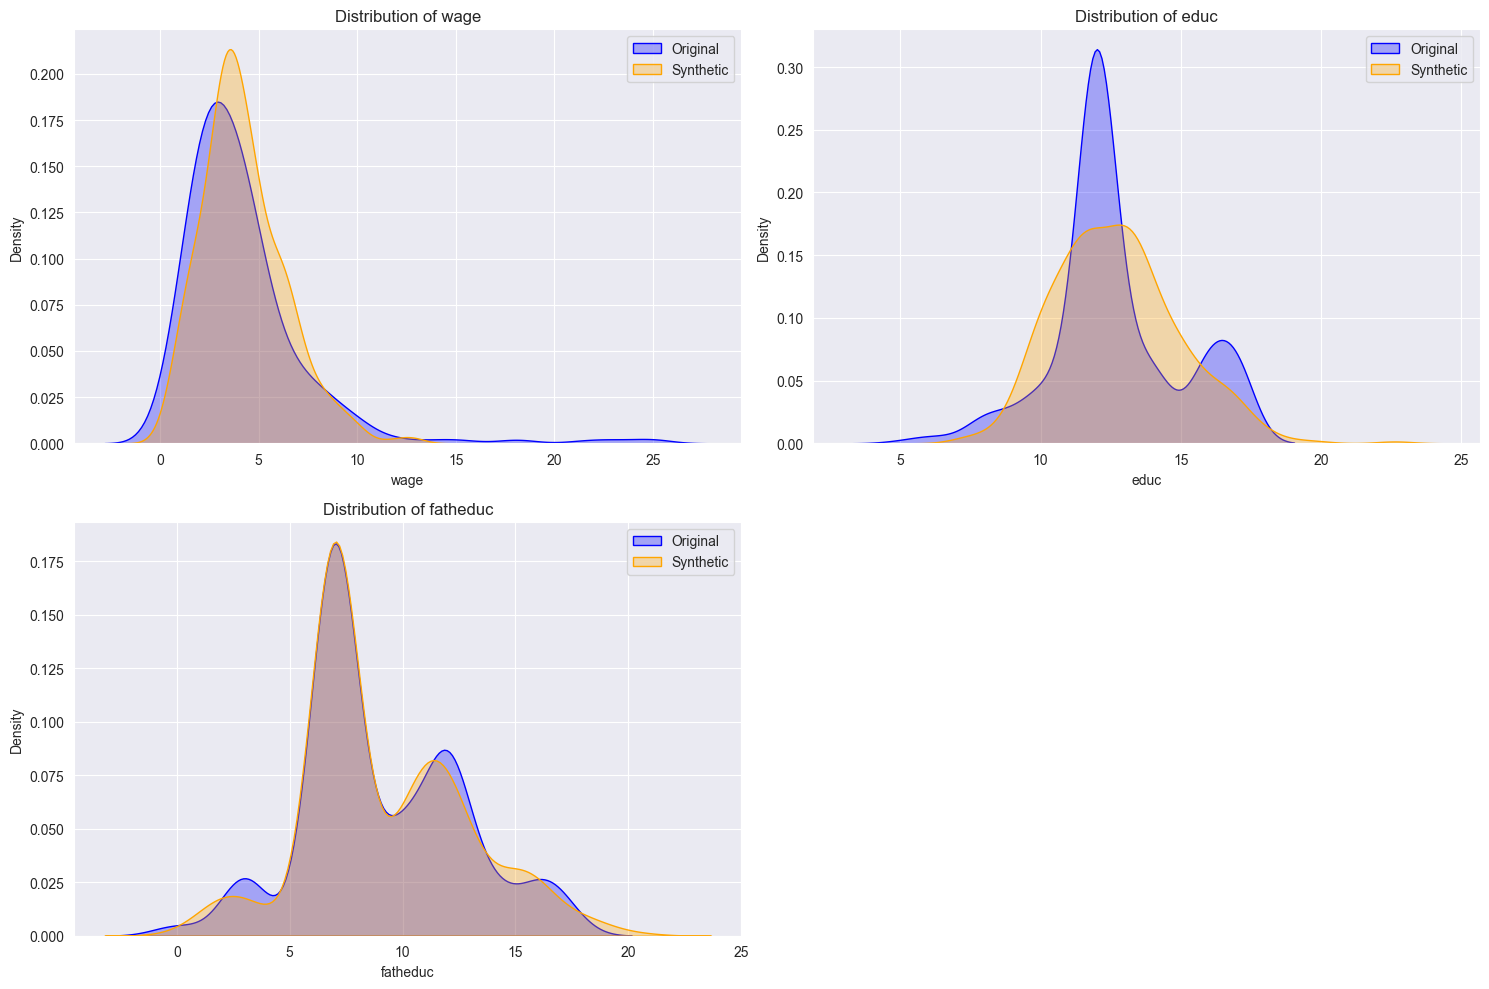

In [255]:
def plot_distributions(original_data, synthetic_data, columns):
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(columns, 1):
        plt.subplot(2, (len(columns) + 1) // 2, i)
        
        # Plot original data
        sns.kdeplot(original_data[col], label="Original", color="blue", fill=True, alpha=0.3)
        
        # Plot synthetic data
        sns.kdeplot(synthetic_data[col], label="Synthetic", color="orange", fill=True, alpha=0.3)
        
        plt.title(f"Distribution of {col}")
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Example usage with your datasets
plot_distributions(data, test_data, columns=columns_of_interest)

In [229]:
res_ols = IV2SLS(np.log(test_data.wage), test_data[["const", "educ"]], None, None).fit(
    cov_type="unadjusted"
)
ols_result = {
    'params': res_ols.params['educ'],
    'CI': res_ols.conf_int().loc['educ'].values,
}
print(res_ols)

                            OLS Estimation Summary                            
Dep. Variable:                   wage   R-squared:                      0.3674
Estimator:                        OLS   Adj. R-squared:                 0.3659
No. Observations:                 428   F-statistic:                    248.53
Date:                Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                        17:27:50   Distribution:                  chi2(1)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -1.2282     0.1635    -7.5104     0.0000     -1.5487     -0.9077
educ           0.1707     0.0108     15.765     0.00

In [230]:
res_first = IV2SLS(test_data.educ, test_data[["const", "fatheduc"]], None, None).fit(
    cov_type="unadjusted"
)
print(res_first)  # F-statistic should be at least 10

res_direct = IV2SLS(np.log(test_data.wage), data["const"], test_data["educ"], instruments=test_data["fatheduc"]).fit(
    cov_type="unadjusted"
)
iv_result = {
    'params': res_direct.params['educ'],
    'CI': res_direct.conf_int().loc['educ'].values,
}
print(res_direct)

                            OLS Estimation Summary                            
Dep. Variable:                   educ   R-squared:                      0.1812
Estimator:                        OLS   Adj. R-squared:                 0.1792
No. Observations:                 428   F-statistic:                    94.686
Date:                Wed, Oct 30 2024   P-value (F-stat)                0.0000
Time:                        17:27:55   Distribution:                  chi2(1)
Cov. Estimator:            unadjusted                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          12.579     0.2614     48.113     0.0000      12.066      13.091
fatheduc       0.2599     0.0267     9.7306     0.00

In [231]:
ols_result, iv_result

({'params': 0.1706653225527484, 'CI': array([0.14944716, 0.19188349])},
 {'params': 0.005696573258303388, 'CI': array([-0.05621986,  0.067613  ])})

# Use BayesFlow

In [161]:
import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

In [232]:
posterior_samples_dict = {
    'instrument_observed': None,
    'no_instrument_observed': None,
}
param_names = ['education']

In [233]:
instrument_observed = True

In [234]:
def generative_model(n_samples: int = None, param_batch: np.ndarray = None):
    if param_batch is None:
        if n_samples is None:
            raise ValueError("Either n_samples or param_batch must be provided.")
        param_batch = np.random.uniform(0, 0.2, size=(n_samples, 1))
    
    # Initialize data array
    sim_data = np.zeros((len(param_batch), data.shape[0], 3 if instrument_observed else 2))
    for i, param in enumerate(param_batch):
        # Generate data for the clinical model with the given parameter
        data_i = econ_model(param[0])  # Only one parameter in the batch
        
        # Include instrument in data if observed, otherwise exclude it
        if instrument_observed:
            data_i = data_i[['wage', 'educ', 'fatheduc']].values
        else:
            data_i = data_i[['wage', 'educ']].values
        sim_data[i] = data_i  # Assign to batch data
    
    return {'sim_data': sim_data, 'prior_draws': param_batch}


In [235]:
summary_net = DeepSet(summary_dim=2)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=3,
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [236]:
np.random.seed(42)
_sim_data = generative_model(1000)
prior_mean = _sim_data['prior_draws'].mean(axis=0)
prior_std = _sim_data['prior_draws'].std(axis=0)
x_mean = np.log1p(_sim_data['sim_data']).mean(axis=(0,1))
x_std = np.log1p(_sim_data['sim_data']).std(axis=(0,1))

In [237]:
def configurator(forward_dict: dict) -> dict:
    # Extract data
    x = forward_dict["sim_data"]
    x = np.log1p(x)
    x = (x - x_mean) / x_std
    out_dict = {
        'summary_conditions': x.astype(np.float32)
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

In [238]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    #checkpoint_path='amortizer_education_IV' if instrument_observed else 'amortizer_education',
)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [239]:
%%time
np.random.seed(42)
offline_data = generative_model(10000)
valid_data = generative_model(256)
prior_draws = valid_data['prior_draws']

CPU times: user 4.7 s, sys: 62.4 ms, total: 4.76 s
Wall time: 4.76 s


In [240]:
if trainer.checkpoint_path is None:
    history = trainer.train_offline(
        simulations_dict=offline_data,
        epochs=30,
        batch_size=128,
        early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

Training epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 1, Loss: 1.164


Training epoch 2:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 2, Loss: 1.206


Training epoch 3:   0%|          | 0/79 [00:00<?, ?it/s]

...

INFO:root:Validation, Epoch: 20, Loss: 0.553


Training epoch 21:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 21, Loss: 0.554


Training epoch 22:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 22, Loss: 0.553
INFO:root:Early stopping triggered.


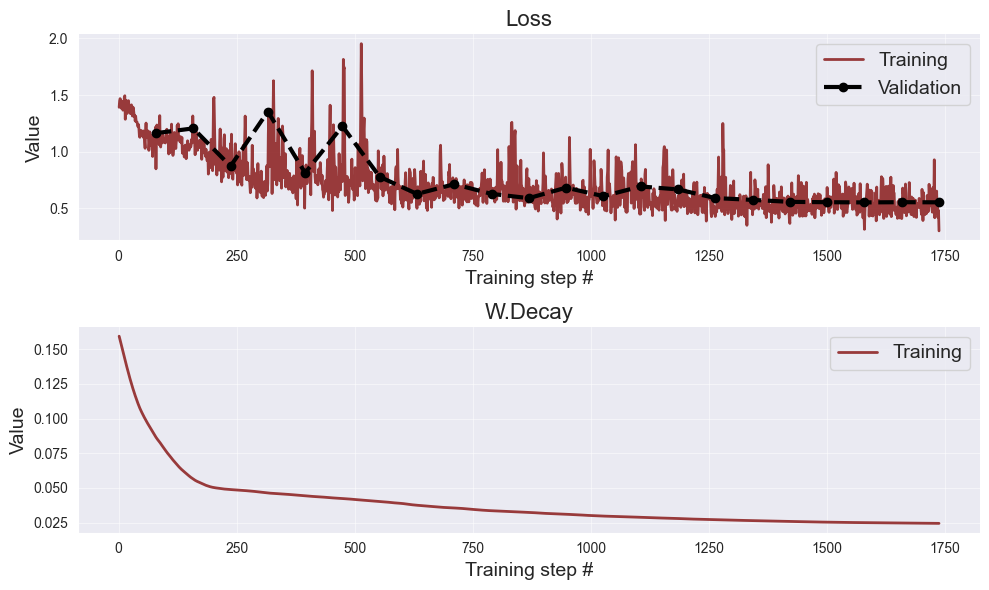

In [241]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [242]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean

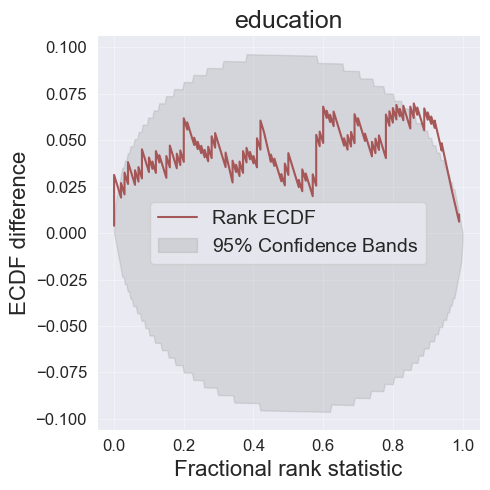

In [243]:
bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names);

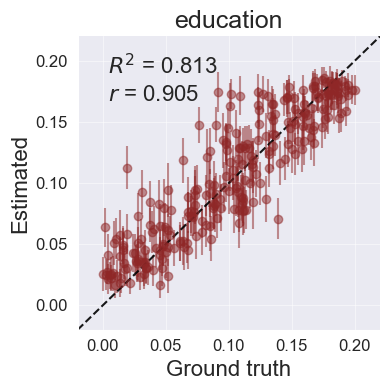

In [244]:
bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names);

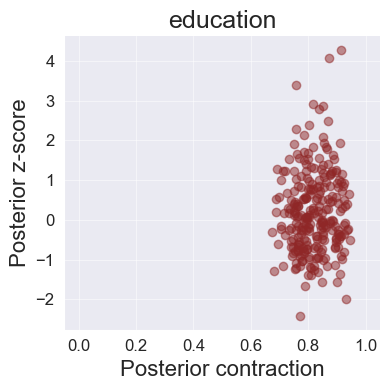

In [245]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

## Test Data

In [252]:
real_data = True

if real_data:
    _test_data = data.copy()
    _ols_result = ols_result_real.copy()
    _iv_result = iv_result_real.copy()
else:
    _test_data = test_data.copy()
    _ols_result = ols_result.copy()
    _iv_result = iv_result.copy()

if instrument_observed:
    _test_data = {'sim_data': _test_data[['wage', 'educ', 'fatheduc']].values[np.newaxis]}
else:
    _test_data = {'sim_data': _test_data[['wage', 'educ']].values[np.newaxis]}
    
# Generate posterior samples using the trainer's amortizer and configurator for the test data
posterior_samples = trainer.amortizer.sample(trainer.configurator(_test_data), n_samples=1000)

# Adjust posterior samples by scaling with prior standard deviation and mean
posterior_samples = posterior_samples * prior_std + prior_mean

# Store posterior samples based on whether the instrument is observed
if instrument_observed:
    posterior_samples_dict['instrument_observed'] = posterior_samples.copy()
else:
    posterior_samples_dict['no_instrument_observed'] = posterior_samples.copy()

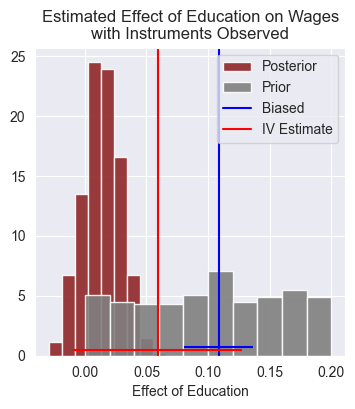

In [253]:
fig = plt.figure(figsize=(4, 4))
plt.hist(posterior_samples, density=True, alpha=0.9, color="#8f2727", label='Posterior')
plt.hist(prior_draws, density=True, alpha=0.9, color="gray", label='Prior')

# Add reference lines for different estimates
plt.axvline(_ols_result['params'], color='b', label='Biased')
plt.errorbar(_ols_result['params'], 0.75, xerr=np.abs(_ols_result['CI'][:, np.newaxis]-_ols_result['params']), color='b')

plt.axvline(_iv_result['params'], color='r', label='IV Estimate')
plt.errorbar(_iv_result['params'], 0.5, xerr=np.abs(_iv_result['CI'][:, np.newaxis]-_iv_result['params']), color='r')

if not real_data:
    plt.axvline(true_param, color='g', label='True')

plt.legend()
plt.xlabel('Effect of Education')
plt.title(f'Estimated Effect of Education on Wages\n{"with Instruments Observed" if instrument_observed else ""}')
plt.show()

In [188]:
if posterior_samples_dict['instrument_observed'] is not None and posterior_samples_dict['no_instrument_observed'] is not None:
    fig = plt.figure(figsize=(4, 4))
    x = np.linspace(0, 0.2, 1000)
    
    # KDE plot for posterior samples with observed instrument
    kde = gaussian_kde(posterior_samples_dict['instrument_observed'].flatten())
    plt.plot(x, kde(x), color='#8f2727', label='Posterior with Observed Instrument')
    
    # KDE plot for posterior samples without observed instrument
    kde_no = gaussian_kde(posterior_samples_dict['no_instrument_observed'].flatten())
    plt.plot(x, kde_no(x), color='#8f5727', label='Posterior')
    
    # Add reference lines for different estimates
    plt.axvline(_ols_result['params'], color='b', label='Biased')
    plt.axvline(_iv_result['params'], color='r', label='IV Estimate')
    if not real_data:
        plt.axvline(true_param, color='g', label='True')
    
    plt.legend(loc='lower left')
    plt.xlabel('Effect of Education')
    plt.title('Posterior Distributions of Education on Wages')
    plt.show()